In [1]:
import os
import cv2
import glob
import torch
import numpy as np
from torch import nn
from pathlib import Path
import matplotlib.pyplot as plt
from torchvision import transforms

In [2]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [3]:
all_pos_filepaths = glob.glob("dataset/train/car/*")
all_neg_filepaths = glob.glob("dataset/train/not_car/*")

## Region Proposal Algorithm - Felzenszwalb segmentation (basically union find hehe)

In [4]:
class Node:
    def __init__(self, pt):
        self.pt = pt
        # to be initialized after a node is instantiated 
        self.parent = None
        self.component = None

class Edge:
    def __init__(self, node1, node2, weight):
        self.node1 = node1
        self.node2 = node2
        self.weight = weight

class Component:
    def __init__(self, size, internal_diff, root):
        self.root = root
        self.size = size
        self.internal_diff = internal_diff
        self.nodes = []

In [5]:
def get_weight(node1, node2, img):
    return int(np.abs(int(img[node1.pt[0], node1.pt[1]]) - int(img[node2.pt[0], node2.pt[1]])))

def add_edge(i, j, edges, img, nodes, kind=0):
    if kind:
        node2 = nodes[util1(i + 1, j, img)]
    else:
        node2 = nodes[util1(i, j + 1, img)]
        
    node1 = nodes[util1(i, j, img)]
    edge_weight = get_weight(node1, node2, img)
    edge = Edge(node1, node2, edge_weight)
    edges.append(edge)

In [6]:
def util1(i, j, img):
    return i * img.shape[1] + j

In [7]:
def create_nodes_components(img):
    # create nodes out of pixels
    # create components out of single pixels (that have been made into nodes)
    
    nodes = []
    components = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
    
            # creating a node out of the pixel first
            node = Node([i, j])
            node.parent = node
            node.component = Component(size=1, internal_diff=-1, root=node)
            components.append(node.component)
            node.component.nodes.append(node)
            nodes.append(node)
    
    return nodes, components

In [8]:
def create_edges(img, nodes):
    edges = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if j + 1 < img.shape[1]:
                add_edge(i, j, edges, img, nodes)
            if i + 1 < img.shape[0]:
                add_edge(i, j, edges, img, nodes, kind=1)
    return edges

In [9]:
def segmentation(edges_sorted):
    k = 10000
    for edge in edges_sorted:
        if edge.node1.component is edge.node2.component:
            continue
        if edge.weight < min(edge.node1.component.internal_diff + k / edge.node1.component.size, edge.node2.component.internal_diff + k / edge.node2.component.size):
            component = edge.node1.component
            edge.node2.parent = component.root
            component.size += edge.node2.component.size
            tmp = edge.node2.component.nodes
            edge.node2.component = component
            for node in tmp:
                node.component = component
                component.nodes.append(node)
            if edge.weight > component.internal_diff:
                component.internal_diff = edge.weight

## Code to see the sengemtnation map

In [10]:
# # # come up weith random color
# # # for each node in a  component, get the nodes pt and draw the color there

# # visited = []
# # canvas = np.ones((img.shape[0], img.shape[1], 3), dtype=np.int16)
# # for component in components:
# #     color = (np.random.randint(255), np.random.randint(255), np.random.randint(255))
# #     for node in component.nodes:
# #         canvas[node.pt[0], node.pt[1]] = color

# final_components = list(set(node.component for node in nodes))

# # give each final component an integer id
# component_to_id = {
#     component: idx
#     for idx, component in enumerate(final_components)
# }

# # create label image
# label_img = np.zeros((img.shape[0], img.shape[1]), dtype=np.int32)

# # fill label image: each pixel gets component id
# for node in nodes:
#     y, x = node.pt
#     label_img[y, x] = component_to_id[node.component]

# # random color for each component
# colors = np.random.randint(
#     0, 255,
#     size=(len(final_components), 3),
#     dtype=np.uint8
# )

# # convert labels to RGB colors
# canvas = colors[label_img]

# plt.figure(figsize=(12, 8))
# plt.imshow(canvas)
# plt.show()

In [11]:
def create_bboxes(nodes):

    # our final components are created, now find min y min x and max y max x for each component 
    # and then create their bbox
    # then filter by area (only area > some n should be taken since we have a lot of tiny components whos bboxes we dont need)

    final_components = list(set(node.component for node in nodes))
    boxes = []
    for component in final_components:
        min_y, min_x, max_y, max_x = np.inf, np.inf, -np.inf, -np.inf
    
        for node in component.nodes:
            y, x = node.pt
    
            if y < min_y:
                min_y = y
    
            if y > max_y:
                max_y = y
    
            if x < min_x:
                min_x = x
    
            if x > max_x:
                max_x = x
    
    
        boxes.append((min_x, min_y, max_x - min_x, max_y - min_y))
    
    # only taking bxoes that are big en ough
    # else you get quite a lot of small components
    final_boxes = []
    for box in boxes:
        x, y, w, h = box
        if w * h > 50: # arbitrary value
            final_boxes.append(box)

    return final_boxes

In [12]:
def region_proposal(img):
    nodes, components = create_nodes_components(img)
    edges = create_edges(img, nodes)
    edges_sorted = sorted(edges, key=lambda e: e.weight)
    segmentation(edges_sorted)
    final_boxes = create_bboxes(nodes)
    return final_boxes

## DeEpLEaRninG

In [13]:
class Dataset(torch.utils.data.Dataset):

    def __init__(self, pos_files_path = "dataset/train/car/", neg_files_path = "dataset/train/not_car/"):
        self.pos_files_path = pos_files_path
        self.neg_files_path = neg_files_path
        self.all_filepaths = glob.glob("dataset/train/car/*") + glob.glob("dataset/train/not_car/*")
        self.labels = torch.from_numpy(np.concatenate([np.ones(len(glob.glob(pos_files_path + '/*'))), np.zeros(len(glob.glob(neg_files_path + '/*')))]))
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize((100, 100)),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])
    
    
    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        img = cv2.imread(self.all_filepaths[idx])
        img = self.transform(img)
        label = self.labels[idx]
        return img, label
        

In [14]:
dataset = Dataset()

num_samples = len(dataset)
indices = np.arange(num_samples)

np.random.seed(42)
np.random.shuffle(indices)

train_ratio = 0.9
train_split = int(train_ratio * len(dataset))
test_split = int(len(dataset) - train_split)

train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_split, test_split])

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

print("Total samples:", len(dataset))
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

Total samples: 4000
Train samples: 3600
Test samples: 400


In [15]:
class Network(nn.Module):

    def __init__(self):
        super().__init__()
        self.conv_net = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LeakyReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.LeakyReLU(),
            nn.BatchNorm2d(128),

            # heheh too much convolition , image was thanos-ed out of existence
            # nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2),
            # nn.MaxPool2d(kernel_size=3, stride=2),
            # nn.LeakyReLU(),
            # nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3, stride=2),
            # nn.MaxPool2d(kernel_size=3, stride=2),
            # nn.LeakyReLU(),
        )
        self.linear_net = nn.Sequential(
            nn.Linear(3200, 2048),
            nn.LeakyReLU(),
            nn.Linear(2048, 1024),
            nn.LeakyReLU(),
            nn.Linear(1024, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 256),
            nn.LeakyReLU(),
            nn.Linear(256, 32),
            nn.LeakyReLU(),
            nn.Linear(32, 1),
        )
        self.sigmoid = nn.Sigmoid()

    
    def forward(self, x):
        batch_size = x.shape[0]
        x = self.conv_net(x)
        x = x.view(batch_size, -1)
        x = self.linear_net(x)
        x = self.sigmoid(x)
        return x

In [16]:
network = Network()
network = network.to(device)

In [17]:
epochs = 10
optimizer = torch.optim.Adam(network.parameters(), lr=3e-4, weight_decay=1e-3)
loss_fn = nn.BCELoss()

In [18]:
# MY LOOP :D

# loss_over_time = []
# for epoch in range(epochs):
#     print(f"Epoch {epoch + 1}/{epochs} started")

#     for batch_idx, (train_img, train_label) in enumerate(dataloader):
#         train_img = train_img.float().to(device)
#         train_label = train_label.float().to(device)

#         output = network(train_img)

#         loss = loss_fn(output.view(-1).float(), train_label.float())
#         loss_over_time.append(loss.item())

#         print(
#             f"Epoch [{epoch + 1}/{epochs}] "
#             f"Batch [{batch_idx + 1}/{len(dataloader)}] "
#             f"Loss: {loss.item():.4f}"
#         )

#         optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()

#     print(f"Epoch {epoch + 1}/{epochs} finished\n")


# NOT MY LOOP WRITING TRAINING LOOPS IS SO AI
train_loss_over_time = []
test_loss_over_time = []

train_acc_over_time = []
test_acc_over_time = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs} started")

    # TRAIN
    network.train()

    total_train_loss = 0
    train_correct = 0
    train_total = 0

    for batch_idx, (train_img, train_label) in enumerate(train_loader):
        train_img = train_img.float().to(device)
        train_label = train_label.float().to(device)

        output = network(train_img)
        output = output.view(-1)

        loss = loss_fn(output, train_label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * train_img.size(0)

        preds = (output >= 0.5).float()

        train_correct += (preds == train_label).sum().item()
        train_total += train_label.size(0)

        train_loss_over_time.append(loss.item())

        if batch_idx % 10 == 0:
            print(
                f"Epoch [{epoch + 1}/{epochs}] "
                f"Batch [{batch_idx + 1}/{len(train_loader)}] "
                f"Train Loss: {loss.item():.4f}"
            )

    avg_train_loss = total_train_loss / train_total
    train_acc = train_correct / train_total

    train_acc_over_time.append(train_acc)

    # TEST
    network.eval()

    total_test_loss = 0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for test_img, test_label in test_loader:
            test_img = test_img.float().to(device)
            test_label = test_label.float().to(device)

            output = network(test_img)
            output = output.view(-1)

            loss = loss_fn(output, test_label)

            total_test_loss += loss.item() * test_img.size(0)

            preds = (output >= 0.5).float()

            test_correct += (preds == test_label).sum().item()
            test_total += test_label.size(0)

    avg_test_loss = total_test_loss / test_total
    test_acc = test_correct / test_total

    test_loss_over_time.append(avg_test_loss)
    test_acc_over_time.append(test_acc)

    print(
        f"Epoch {epoch + 1}/{epochs} finished | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Loss: {avg_test_loss:.4f} | "
        f"Test Acc: {test_acc:.4f}\n"
    )

Epoch 1/10 started
Epoch [1/10] Batch [1/113] Train Loss: 0.6997
Epoch [1/10] Batch [11/113] Train Loss: 0.5557
Epoch [1/10] Batch [21/113] Train Loss: 0.3599
Epoch [1/10] Batch [31/113] Train Loss: 0.2480
Epoch [1/10] Batch [41/113] Train Loss: 0.3207
Epoch [1/10] Batch [51/113] Train Loss: 0.1595
Epoch [1/10] Batch [61/113] Train Loss: 0.3009
Epoch [1/10] Batch [71/113] Train Loss: 0.2582
Epoch [1/10] Batch [81/113] Train Loss: 0.2483
Epoch [1/10] Batch [91/113] Train Loss: 0.3167
Epoch [1/10] Batch [101/113] Train Loss: 0.0868
Epoch [1/10] Batch [111/113] Train Loss: 0.3530
Epoch 1/10 finished | Train Loss: 0.3109 | Train Acc: 0.8606 | Test Loss: 0.2241 | Test Acc: 0.8975

Epoch 2/10 started
Epoch [2/10] Batch [1/113] Train Loss: 0.1439
Epoch [2/10] Batch [11/113] Train Loss: 0.2331
Epoch [2/10] Batch [21/113] Train Loss: 0.1564
Epoch [2/10] Batch [31/113] Train Loss: 0.1725
Epoch [2/10] Batch [41/113] Train Loss: 0.1039
Epoch [2/10] Batch [51/113] Train Loss: 0.2186
Epoch [2/10] Ba

## Give a test image and test out the detection

In [25]:
img = cv2.imread("test.png")

In [26]:
def preprocess_patch(patch):
    # patch: numpy image, shape H,W,3

    # resize to classifier input size
    patch = cv2.resize(patch, (100, 100))

    # # BGR -> RGB if image came from cv2
    # patch = cv2.cvtColor(patch, cv2.COLOR_BGR2RGB)

    # H,W,C -> C,H,W
    print(patch.shape)
    patch = torch.from_numpy(patch).permute(2, 0, 1).float()

    # 0-255 -> 0-1
    patch = patch / 255.0

    # normalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    patch = (patch - mean) / std

    # add batch dimension: C,H,W -> 1,C,H,W
    patch = patch.unsqueeze(0)

    return patch

In [27]:
# since the patch is a tensor and needs to be properly converted back to an image before displaying
def show_patch(patch):
    # patch shape couolld be [1, 3, 100, 100] or [3, 100, 100]

    if patch.dim() == 4:
        patch = patch[0]   # [1, 3, H, W] -> [3, H, W]

    patch = patch.detach().cpu()

    # unnormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    patch = patch * std + mean
    patch = torch.clamp(patch, 0, 1)

    # C, H, W -> H, W, C
    patch = patch.permute(1, 2, 0)

    plt.imshow(patch)
    plt.axis("off")
    plt.show()

In [28]:
# sinmple functoin to run region propsosal and sengmetna and then detec object on only the bboxes above a certain size ( area)
def detect_object(img):
    
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    bboxes = region_proposal(gray_img)
    for bbox in bboxes:
        x, y, w, h = bbox
        patch = img[y:y + h, x:x + w, :]
        # this patch has to be 100x100 for my classifier
        patch = preprocess_patch(patch)

        patch = patch.to(device)
        output = network(patch)
        if output > .5:
            print(f"YES OBJECT")
            show_patch(patch)
        # else:
        #     print(f"NO OBJECT")
        #     show_patch(patch)

(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
YES OBJECT


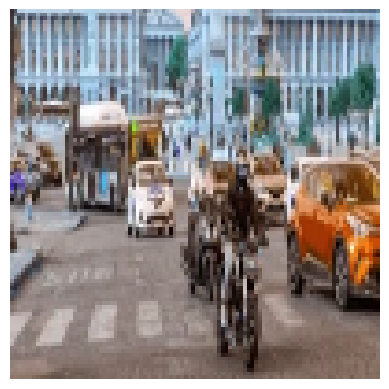

(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
YES OBJECT


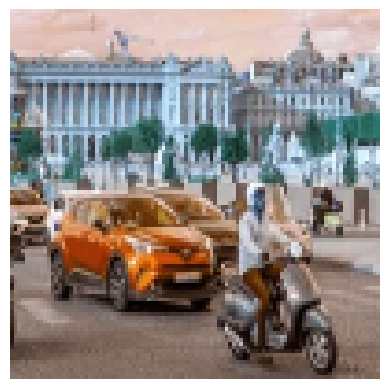

(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
YES OBJECT


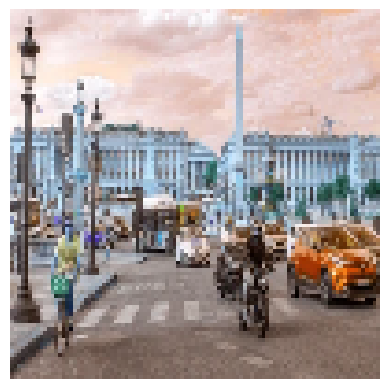

(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)
(100, 100, 3)


In [29]:
detect_object(img)